# CMAPSS — RNN / LSTM / GRU con Cross-Validation

In [40]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupKFold
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42)
torch.manual_seed(42)

In [41]:
BASE_PATH = Path.cwd().parents[1]
BASE_RESULTS_PATH = BASE_PATH / "results" / "CMAPSS" / "Cross_Validation" / "Summary"

RAW_PATH     = BASE_PATH / "data" / "raw" / "CMAPSS"
MODEL_PATH   = BASE_RESULTS_PATH / "models_CV"
FIG_PATH     = BASE_RESULTS_PATH / "figures_CV"
METRICS_PATH = BASE_RESULTS_PATH / "metrics_CV"
REPORTS_PATH = BASE_RESULTS_PATH / "reports_CV"
FINAL_PATH   = BASE_RESULTS_PATH / "Final_CV_Result"

for p in [MODEL_PATH, FIG_PATH, METRICS_PATH, REPORTS_PATH, FINAL_PATH]:
    p.mkdir(parents=True, exist_ok=True)

for sub in ["tables","figures","reports"]:
    (FINAL_PATH / sub).mkdir(exist_ok=True)

print("RAW_PATH:", RAW_PATH)


RAW_PATH: c:\Users\David\Documents\AeroGPT\data\raw\CMAPSS


## 3) Carga y preprocesado

Funciones para cargar los archivos CMAPSS, añadir RUL, comprobar nulos, eliminar columnas constantes, escalar y crear secuencias

In [42]:
def load_fd_dataset(fd):
    cols = ['unit_nr','time_cycles','setting_1','setting_2','setting_3'] \
           + [f's_{i}' for i in range(1,22)]
    train = pd.read_csv(RAW_PATH / f"train_{fd}.txt", sep="\s+", names=cols)
    test  = pd.read_csv(RAW_PATH / f"test_{fd}.txt",  sep="\s+", names=cols)
    rul   = pd.read_csv(RAW_PATH / f"RUL_{fd}.txt",   sep="\s+", names=["RUL"])
    return train, test, rul

def add_rul(df):
    max_cycle = df.groupby("unit_nr")["time_cycles"].max()
    return df.assign(RUL=df["unit_nr"].map(max_cycle) - df["time_cycles"])

def remove_constant_columns(train, test, features):
    drop = []
    for c in features:
        if pd.concat([train[c], test[c]]).std() == 0:
            drop.append(c)
    return train.drop(columns=drop), test.drop(columns=drop), drop

def scale_features(train, test, features):
    scaler = StandardScaler()
    train[features] = scaler.fit_transform(train[features])
    test[features]  = scaler.transform(test[features])
    return train, test, scaler

def create_sequences(df, features, target, window):
    X,y,u = [],[],[]
    for unit in df.unit_nr.unique():
        d = df[df.unit_nr==unit].sort_values("time_cycles")
        f = d[features].values
        t = d[target].values
        for i in range(len(d)-window+1):
            X.append(f[i:i+window])
            y.append(t[i+window-1])
            u.append(unit)
    return np.array(X), np.array(y), np.array(u)

def create_test_window(test, rul, features, window):
    X,y,u = [],[],[]
    for i,unit in enumerate(test.unit_nr.unique()):
        d = test[test.unit_nr==unit].sort_values("time_cycles")
        seq = d[features].values[-window:]
        if len(seq) < window:
            seq = np.vstack([np.zeros((window-len(seq),seq.shape[1])), seq])
        X.append(seq); y.append(rul.iloc[i,0]); u.append(unit)
    return np.array(X), np.array(y), np.array(u)

## 4) Modelos: GRU, LSTM y RNN

In [43]:
def nasa_score(y_true, y_pred):
    s = 0.0
    for yt, yp in zip(y_true, y_pred):
        d = yp - yt
        s += np.exp(-d/13)-1 if d < 0 else np.exp(d/10)-1
    return s / len(y_true)

def rmse_trunc(y_true, y_pred, cap=125):
    return np.sqrt(mean_squared_error(
        np.minimum(y_true, cap),
        np.minimum(y_pred, cap)
    ))

def mae_low_rul(y_true, y_pred, thr=50):
    m = y_true <= thr
    return mean_absolute_error(y_true[m], y_pred[m]) if m.sum() > 0 else np.nan


In [44]:
class BaseRNN(nn.Module):
    def __init__(self, rnn_layer, input_dim,
                 hidden=(256,128), layers=2, dropout=0.3):
        super().__init__()
        self.rnn1 = rnn_layer(input_dim, hidden[0],
                              num_layers=layers,
                              dropout=dropout,
                              batch_first=True)
        self.rnn2 = rnn_layer(hidden[0], hidden[1],
                              num_layers=layers,
                              dropout=dropout,
                              batch_first=True)
        self.fc = nn.Linear(hidden[1], 1)

    def forward(self, x):
        x,_ = self.rnn1(x)
        x,_ = self.rnn2(x)
        return self.fc(x[:, -1, :])

class GRUModel(BaseRNN):
    def __init__(self, input_dim):
        super().__init__(nn.GRU, input_dim)

class LSTMModel(BaseRNN):
    def __init__(self, input_dim):
        super().__init__(nn.LSTM, input_dim)

class RNNModel(BaseRNN):
    def __init__(self, input_dim):
        super().__init__(nn.RNN, input_dim)


## 5) Funciones entrenamiento y evaluación

Funciones para entrenar una época, evaluar y entrenar con early stopping y ReduceLROnPlateau.

In [45]:
def train_epoch(model, loader, opt, loss_fn):
    model.train(); tot=0
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        l = loss_fn(model(x),y)
        l.backward(); opt.step()
        tot += l.item()*len(x)
    return tot/len(loader.dataset)

def eval_model(model, loader):
    model.eval(); p,t=[],[]
    with torch.no_grad():
        for x,y in loader:
            p.append(model(x.to(DEVICE)).cpu().numpy())
            t.append(y.numpy())
    p,t = np.vstack(p).ravel(), np.vstack(t).ravel()
    return {
        "RMSE": np.sqrt(mean_squared_error(t,p)),
        "MAE": mean_absolute_error(t,p),
        "RMSE_trunc": rmse_trunc(t,p),
        "MAE_low": mae_low_rul(t,p),
        "NASA": nasa_score(t,p)
    }, p, t

def fit(model, tr_loader, va_loader, epochs=200, lr=5e-4, patience=20):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8)
    loss_fn = nn.MSELoss()
    best,wait = np.inf,0
    for e in range(epochs):
        tr = train_epoch(model,tr_loader,opt,loss_fn)
        va,_ ,_ = eval_model(model,va_loader)
        sch.step(va["RMSE"])
        if va["RMSE"] < best:
            best = va["RMSE"]; wait=0
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        else:
            wait+=1
        if wait>=patience: break
    model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    return model

## 6) Preprocesado, CV por grupos, entrenamiento y guardado

In [46]:
FD_LIST = ["FD001","FD002","FD003","FD004"]
WINDOW  = 50
ALGS = {"GRU":GRUModel,"LSTM":LSTMModel,"RNN":RNNModel}

for fd in FD_LIST:
    train,test,rul = load_fd_dataset(fd)
    train = add_rul(train)

    FEATURES = ['setting_1','setting_2','setting_3']+[f's_{i}' for i in range(1,22)]
    train,test,_ = remove_constant_columns(train,test,FEATURES)
    FEATURES = [c for c in FEATURES if c in train.columns]
    train,test,scaler = scale_features(train,test,FEATURES)

    X,y,u = create_sequences(train,FEATURES,"RUL",WINDOW)
    gkf = GroupKFold(5)

    cv_rows = []
    for name,Cls in ALGS.items():
        for f,(tr,va) in enumerate(gkf.split(X,y,u),1):
            mdl = Cls(len(FEATURES))
            trL = DataLoader(TensorDataset(
                torch.tensor(X[tr]).float(),
                torch.tensor(y[tr]).float().view(-1,1)),32,True)
            vaL = DataLoader(TensorDataset(
                torch.tensor(X[va]).float(),
                torch.tensor(y[va]).float().view(-1,1)),64)
            mdl = fit(mdl,trL,vaL)
            m,_,_ = eval_model(mdl,vaL)
            cv_rows.append({"FD":fd,"Model":name,"Fold":f,**m})

    cv_df = pd.DataFrame(cv_rows)
    cv_df.to_csv(FINAL_PATH/"tables"/f"{fd}_cv_summary.csv",index=False)

    # Entrenamiento final + test
    Xt,Yt,Ut = create_test_window(test,rul,FEATURES,WINDOW)
    res=[]
    for name,Cls in ALGS.items():
        mdl = fit(Cls(len(FEATURES)),
                  DataLoader(TensorDataset(torch.tensor(X).float(),
                                           torch.tensor(y).float().view(-1,1)),32,True),
                  DataLoader(TensorDataset(torch.tensor(X).float(),
                                           torch.tensor(y).float().view(-1,1)),64))
        m,p,t = eval_model(mdl,
            DataLoader(TensorDataset(torch.tensor(Xt).float(),
                                     torch.tensor(Yt).float().view(-1,1)),64))
        res.append({"FD":fd,"Model":name,**m})

        plt.figure(figsize=(9,4))
        plt.plot(t,label="True"); plt.plot(p,label="Pred")
        plt.legend(); plt.title(f"{fd} {name}")
        plt.savefig(FINAL_PATH/"figures"/f"{fd}_{name}_pred.png")
        plt.close()

    pd.DataFrame(res).to_csv(FINAL_PATH/"tables"/f"{fd}_test_summary.csv",index=False)


## 7. Síntesis final de resultados

En esta sección se consolidan todas las métricas de validación cruzada generadas en las fases anteriores
con el objetivo de producir tablas y figuras finales, suficientes para  comparación
global de arquitecturas.


In [51]:
import glob
import seaborn as sns

FINAL_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH = FINAL_PATH / "tables"

FINAL_PATH

WindowsPath('c:/Users/David/Documents/AeroGPT/results/CMAPSS/Cross_Validation/Summary/Final_CV_Result')

In [56]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

BASE_PATH = Path.cwd().parents[1]

FINAL_PATH = (
    BASE_PATH
    / "results"
    / "CMAPSS"
    / "Cross_Validation"
    / "Summary"
    / "Final_CV_Result"
)

TABLES_PATH = FINAL_PATH / "tables"

In [57]:
csv_files = glob.glob(str(TABLES_PATH / "FD00*_*.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)

    fd, split = Path(file).stem.split("_", 1)
    split = split.replace("_summary", "")

    df["FD"] = fd
    df["Split"] = split
    dfs.append(df)

metrics_df = pd.concat(dfs, ignore_index=True)
display(metrics_df.head())


,FD,Model,Fold,RMSE,MAE,RMSE_trunc,MAE_low,NASA,Split
0,FD001,GRU,1.0,30.146512,18.180573,12.452945,4.551493,2324.89140,cv
1,FD001,GRU,2.0,27.736053,17.119493,12.982105,4.036695,1031.21980,cv
2,FD001,GRU,3.0,27.498038,17.315340,14.039399,4.410327,207.46791,cv
3,FD001,GRU,4.0,26.918174,17.440813,14.078490,4.648381,86.34976,cv
4,FD001,GRU,5.0,25.515150,17.572290,14.264737,5.916885,35.59566,cv


Comprobaciones

In [58]:
required_cols = {"FD", "Model", "RMSE", "MAE", "NASA", "Split"}
missing = required_cols - set(metrics_df.columns)

if missing:
    raise ValueError(f"Faltan columnas: {missing}")

print("CSV validados correctamente")


CSV validados correctamente


Limpieza

In [59]:
metrics_df["Fold"] = metrics_df.get("Fold", pd.Series(dtype="Int64"))

metrics_df = metrics_df[
    ["FD", "Model", "Fold", "RMSE", "MAE", "RMSE_trunc", "MAE_low", "NASA", "Split"]
]


Resumen CV

In [60]:
cv_df = metrics_df.query("Split == 'cv'")

cv_summary = (
    cv_df
    .groupby(["FD", "Model"])
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        NASA_mean=("NASA", "mean"),
        NASA_std=("NASA", "std"),
        n_folds=("RMSE", "count")
    )
    .reset_index()
)

display(cv_summary)


,FD,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,NASA_mean,NASA_std,n_folds
0,FD001,GRU,27.562785,1.682126,17.525702,0.402334,7.371049e+02,9.751516e+02,5
1,FD001,LSTM,45.623546,14.722852,34.912282,15.187553,7.925579e+03,8.679707e+03,5
2,FD001,RNN,46.242056,10.657086,35.698716,10.573949,6.380441e+03,9.449553e+03,5
3,FD002,GRU,33.184749,3.700420,23.206709,3.757819,1.708239e+03,1.353807e+03,5
4,FD002,LSTM,41.920875,14.661640,31.618343,13.830051,4.782188e+04,9.132342e+04,5
5,FD002,RNN,52.359519,11.910989,41.371909,11.790880,6.668061e+04,8.649289e+04,5
6,FD003,GRU,44.261758,1.938775,27.959302,1.746911,2.724284e+04,2.536591e+04,5
7,FD003,LSTM,61.706452,25.854302,44.501255,23.153524,6.640884e+07,9.994731e+07,5
8,FD003,RNN,48.848965,9.049530,33.155228,7.764761,1.456055e+05,2.735693e+05,5
9,FD004,GRU,47.602444,7.921674,33.177975,6.442484,5.450660e+06,1.198237e+07,5


TEST + CONSOLIDADO

In [61]:
test_summary = (
    metrics_df.query("Split == 'test'")
    .groupby(["FD", "Model"])
    .agg(
        RMSE_test=("RMSE", "mean"),
        MAE_test=("MAE", "mean"),
        NASA_test=("NASA", "mean")
    )
    .reset_index()
)

final_table = cv_summary.merge(test_summary, on=["FD", "Model"], how="left")
display(final_table)


,FD,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,NASA_mean,NASA_std,n_folds,RMSE_test,MAE_test,NASA_test
0,FD001,GRU,27.562785,1.682126,17.525702,0.402334,7.371049e+02,9.751516e+02,5,28.444685,20.302404,303.448000
1,FD001,LSTM,45.623546,14.722852,34.912282,15.187553,7.925579e+03,8.679707e+03,5,27.549029,19.505896,336.442400
2,FD001,RNN,46.242056,10.657086,35.698716,10.573949,6.380441e+03,9.449553e+03,5,27.306729,18.645357,277.793670
3,FD002,GRU,33.184749,3.700420,23.206709,3.757819,1.708239e+03,1.353807e+03,5,33.332443,23.926546,417.438600
4,FD002,LSTM,41.920875,14.661640,31.618343,13.830051,4.782188e+04,9.132342e+04,5,26.116017,19.277967,45.328037
5,FD002,RNN,52.359519,11.910989,41.371909,11.790880,6.668061e+04,8.649289e+04,5,53.930212,45.467731,549.017100
6,FD003,GRU,44.261758,1.938775,27.959302,1.746911,2.724284e+04,2.536591e+04,5,34.251404,21.277250,446806.840000
7,FD003,LSTM,61.706452,25.854302,44.501255,23.153524,6.640884e+07,9.994731e+07,5,58.952688,47.796436,6436.251500
8,FD003,RNN,48.848965,9.049530,33.155228,7.764761,1.456055e+05,2.735693e+05,5,43.133137,28.654715,231172.500000
9,FD004,GRU,47.602444,7.921674,33.177975,6.442484,5.450660e+06,1.198237e+07,5,42.036226,31.393700,6661.653000


RANKING

In [62]:
rank_df = cv_summary.copy()

for m in ["RMSE_mean", "NASA_mean"]:
    rank_df[f"{m}_norm"] = (
        rank_df.groupby("FD")[m]
        .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )

rank_df["Score"] = 0.6 * rank_df["RMSE_mean_norm"] + 0.4 * rank_df["NASA_mean_norm"]

ranking = (
    rank_df
    .sort_values(["FD", "Score"])
    .assign(Rank=lambda d: d.groupby("FD").cumcount() + 1)
)

display(ranking)


,FD,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,NASA_mean,NASA_std,n_folds,RMSE_mean_norm,NASA_mean_norm,Score,Rank
0,FD001,GRU,27.562785,1.682126,17.525702,0.402334,7.371049e+02,9.751516e+02,5,0.000000,0.000000,0.000000,1
2,FD001,RNN,46.242056,10.657086,35.698716,10.573949,6.380441e+03,9.449553e+03,5,1.000000,0.785053,0.914021,2
1,FD001,LSTM,45.623546,14.722852,34.912282,15.187553,7.925579e+03,8.679707e+03,5,0.966888,1.000000,0.980133,3
3,FD002,GRU,33.184749,3.700420,23.206709,3.757819,1.708239e+03,1.353807e+03,5,0.000000,0.000000,0.000000,1
4,FD002,LSTM,41.920875,14.661640,31.618343,13.830051,4.782188e+04,9.132342e+04,5,0.455605,0.709742,0.557260,2
5,FD002,RNN,52.359519,11.910989,41.371909,11.790880,6.668061e+04,8.649289e+04,5,1.000000,1.000000,1.000000,3
6,FD003,GRU,44.261758,1.938775,27.959302,1.746911,2.724284e+04,2.536591e+04,5,0.000000,0.000000,0.000000,1
8,FD003,RNN,48.848965,9.049530,33.155228,7.764761,1.456055e+05,2.735693e+05,5,0.262957,0.001783,0.158488,2
7,FD003,LSTM,61.706452,25.854302,44.501255,23.153524,6.640884e+07,9.994731e+07,5,1.000000,1.000000,1.000000,3
9,FD004,GRU,47.602444,7.921674,33.177975,6.442484,5.450660e+06,1.198237e+07,5,0.000000,0.000000,0.000000,1


GRAFICAS

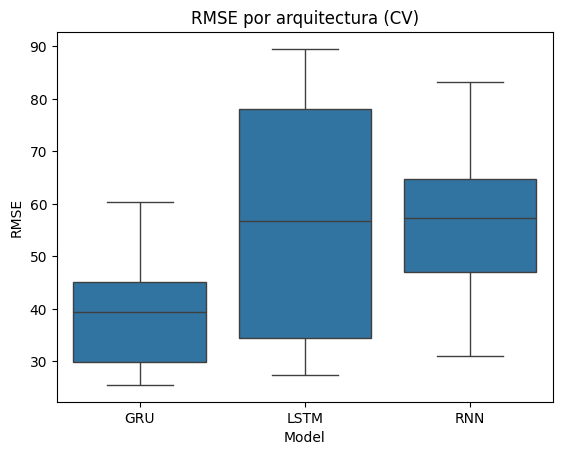

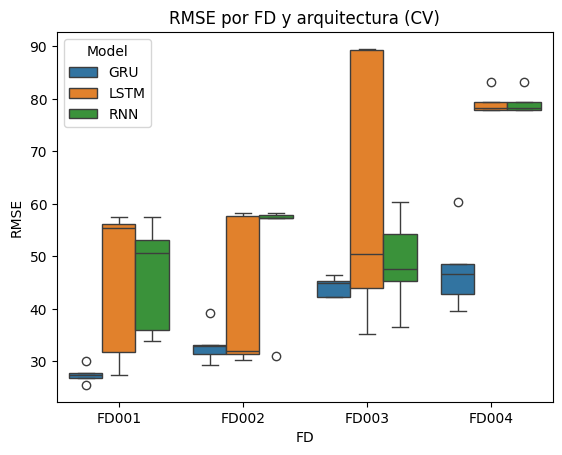

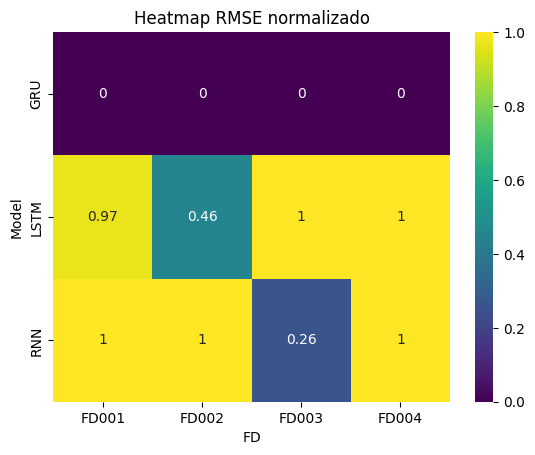

In [63]:
sns.boxplot(data=cv_df, x="Model", y="RMSE")
plt.title("RMSE por arquitectura (CV)")
plt.show()

sns.boxplot(data=cv_df, x="FD", y="RMSE", hue="Model")
plt.title("RMSE por FD y arquitectura (CV)")
plt.show()

pivot = cv_summary.pivot(index="Model", columns="FD", values="RMSE_mean")
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

sns.heatmap(pivot_norm, annot=True, cmap="viridis")
plt.title("Heatmap RMSE normalizado")
plt.show()
